In [1]:
%run start
%load_ext autoreload
%autoreload 2

Root set to: /home/bdudas/obesity_challange


In [2]:
from CycleTransformer.dataloader import get_predifinedLoaders as get_loaders
from CycleTransformer.dataloader import CellDataset, get_dataBence
from omegaconf import OmegaConf
import pytorch_lightning as pl
from lightning.pytorch.loggers import MLFlowLogger
from pytorch_lightning.callbacks import ModelCheckpoint
from CycleTransformer.cycleTransformer import CycleTransformer
import torch
import anndata as ad

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cfg = OmegaConf.load("config.yaml")

In [3]:
adata = ad.read_h5ad("data/obesity_challenge_1.h5ad")


In [8]:
adata.var_names = [ i + str("abc")for i in adata.var_names]
newvarnnames = adata.var_names

In [ ]:
truthList = [i>13000 for i in range(len(adata.var_names))]
adata.var[truthList] 

In [11]:
adata.var

""
INO80Cabcabc
AC008507.4abcabc
AC015849.4abcabc
CNDP1abcabc
ANXA9abcabc
...
DCLK1abcabc
AC010623.1abcabc
B3GLCTabcabc
PALMDabcabc


In [4]:
trainloader, valloader, *_ = get_loaders(batch_size=cfg.batch_size, num_workers=cfg.num_workers)
modelKwargs = cfg.model_kwargs
model = CycleTransformer(phase=1,**modelKwargs)

Train genes: 122, Val genes: 122
Train genes: 121, Val genes: 121


/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [5]:
model = CycleTransformer(phase=1,**modelKwargs)

mlflow_logger = MLFlowLogger(experiment_name=cfg.experiment_name,run_name=cfg.run_name)
trainer = pl.Trainer(max_epochs=cfg.max_epochs,logger=mlflow_logger,accelerator="auto",devices="auto"
                            )


/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs autom

In [7]:
trainer.fit(model, trainloader, valloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


┏━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name             ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ encoder          │ TransformerCycleEncoder   │  5.4 M │ train │     0 │
│ 1  │ decoder          │ TransformerCycleDecoder   │  5.4 M │ train │     0 │
│ 2  │ transition_fwd   │ DeltaTransition           │  1.4 M │ eval  │     0 │
│ 3  │ transition_bwd   │ DeltaTransition           │  1.4 M │ eval  │     0 │
│ 4  │ latentClassifier │ LatentClassifier          │ 33.7 K │ train │     0 │
│ 5  │ discriminator    │ SemanticDiscriminator     │  394 K │ eval  │     0 │
│ 6  │ criterion        │ MSELoss                   │      0 │ train │     0 │
│ 7  │ latent_criterion │ CrossEntropyLoss          │      0 │ train │     0 │
│ 8  │ center_loss      │ CenterLoss                │  1.0 K │ train │     0 │
│ 9  │ aucMetric        │ MulticlassAUROC           │      0 │ train │     0 │
│ 10 │ confmat          │ MulticlassConfusionMatrix │      0 │ train │     0 │
│ 11 │ confmat2         │ MulticlassConfusionMatrix │      0 │ train │     0 │
│ 12 │ classwise_auc    │ ClasswiseWrapper          │      0 │ train │     0 │
└────┴──────────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 10.9 M                                                                                           
Non-trainable params: 3.3 M                                                                                        
Total params: 14.2 M                                                                                               
Total estimated model params size (MB): 56                                                                         
Modules in train mode: 105                                                                                         
Modules in eval mode: 45                                                                                           
Total FLOPs: 0

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:534: Found 45 
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

KeyError: Caught KeyError in DataLoader worker process 3.
Original Traceback (most recent call last):
  File "/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/home/bdudas/obesity_challange/CycleTransformer/dataloader.py", line 48, in __getitem__
    gene_idx = self.gene_to_idx[gene_name]
KeyError: 'FLI1'


In [14]:
train_path = "data/GW_train"
val_path = "data/GW_test"
num_workers = cfg.num_workers
batch_size = cfg.batch_size
adata_train, gene_to_idx, idx_to_gene = get_dataBence(train_path)
adata_val, _, _ = get_dataBence(val_path)
ctrl_data = adata_train[adata_train.obs.gene == "NC"]
target_data = adata_train[(adata_train.obs.gene != "NC") & (adata_train.obs.gene.isin(adata_train.var_names))]
val_data = adata_val[(adata_val.obs.gene != "NC") & (adata_val.obs.gene.isin(adata_val.var_names))]
pin_memory = True if num_workers > 0 else False
persistent_workers = True if num_workers > 0 else False
dataset = CellDataset(target_data, ctrl_data, gene_to_idx)
val_dataset = CellDataset(val_data, ctrl_data, gene_to_idx)
trainloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size,shuffle= True,num_workers=num_workers,persistent_workers=persistent_workers,pin_memory=pin_memory)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size = batch_size,shuffle= False,num_workers=num_workers,persistent_workers=persistent_workers,pin_memory=pin_memory)


In [4]:
adata = ad.read_h5ad('data/obesity_challenge_1.h5ad')

In [33]:
adata[adata.obs.gene == "NC"].write_h5ad('data/ctrl_data.h5ad')

In [5]:
geneData = adata[adata.obs.gene != "NC"]

In [9]:
import numpy as np

In [10]:
val_genes = np.random.choice(adata.obs.gene.unique(), size=20, replace=False)

In [13]:
trainData = geneData[~geneData.obs.gene.isin(val_genes)]
test_data = geneData[geneData.obs.gene.isin(val_genes)]

In [15]:
trainData.obs.gene.unique()

['HIF1A', 'ZNF26', 'TWIST1', 'CEBPA', 'TSHZ2', ..., 'CNOT8', 'CEBPB', 'EEF1A1', 'HMGA1', 'SRPK1']
Length: 102
Categories (102, object): ['AATF', 'ABT1', 'AFF1', 'ANKRA2', ..., 'ZNF331', 'ZNF354B', 'ZNF419', 'ZNF480']

In [16]:
test_data.obs.gene.unique()

['HIF3A', 'FOXP1', 'PBX3', 'ZFY', 'ZNF254', ..., 'PLAGL1', 'PBX1', 'CIC', 'KLF15', 'CREG1']
Length: 20
Categories (20, object): ['CIC', 'CREG1', 'FOXP1', 'HDAC2', ..., 'ZNF44', 'ZNF138', 'ZNF254', 'ZNF334']

In [38]:
trainData, test_data = torch.utils.data.random_split(geneData, [int(0.9*len(geneData)), len(geneData)-int(0.9*len(geneData))])

In [55]:
numSamples = geneData.shape[0]
numTrain = int(0.9*numSamples)
rdidxs = torch.randperm(numSamples)
trainData = geneData[rdidxs[:numTrain].numpy()]
testData = geneData[rdidxs[numTrain:].numpy()]

In [17]:
trainData.write_h5ad('data/train_data.h5ad')


In [19]:
test_data.write_h5ad('data/test_data.h5ad')

In [60]:
adata.var_names

Index(['INO80C', 'AC008507.4', 'AC015849.4', 'CNDP1', 'ANXA9', 'PROS1',
       'HACD2', 'Z98752.4', 'AL162734.1', 'PCLAF',
       ...
       'AC006538.1', 'TXN2', 'LINC02137', 'ZNF23', 'PSG4', 'DCLK1',
       'AC010623.1', 'B3GLCT', 'PALMD', 'LINC02102'],
      dtype='object', name='gene', length=21592)

In [63]:
gene_to_idx = {g: i for i, g in enumerate(adata.var.index.to_numpy())}

In [64]:
import pickle

In [65]:
with open('data/gene_to_idx.pkl', 'wb') as f:
    pickle.dump(gene_to_idx, f)

# Old

In [5]:
trainloader, valloader, gene_to_index, index_to_gene = get_loaders("",batch_size=cfg.batch_size,num_workers=cfg.num_workers)  

In [10]:
from src.models.CycleTransformer import CycleTransformer


In [11]:
cpkt_name ="latent_reg"
pretrained_path = f"misc/best_runs/{cpkt_name}/checkpoints/best-checkpoint.ckpt"
model = CycleTransformer.load_from_checkpoint(checkpoint_path = pretrained_path)#(**modelKwargs)
model.configure_cycle()

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [12]:
cpkt_callback = ModelCheckpoint(monitor="val/g_total_loss",mode="min",save_top_k=1,filename="best-checkpoint")
mlflow_logger = MLFlowLogger(experiment_name=cfg.experiment_name,run_name=cfg.run_name)
trainer = pl.Trainer(max_epochs=cfg.max_epochs,logger=mlflow_logger,accelerator="auto",devices="auto" ,callbacks=[cpkt_callback])


Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

   | Name             | Type                      | Params | Mode  | FLOPs
--------------------------------------------------------------------------------
0  | encoder          | TransformerCycleEncoder   | 5.4 M  | eval  | 0    
1  | decoder          | TransformerCycleDecoder   | 5.4 M  | eval  | 0    
2  | transition       | LatentTransition2         | 7.9 M  | eval  | 0    
3  | latentClassifier | LatentClassifier          | 33.7 K | eval  | 0    
4  | criterion        | MSELoss                   | 0      | train | 0    
5  | latent_criterion | CrossEntropyLoss          | 0      | train | 0    
6  | center_loss      | CenterLoss                | 1.0 K  | train | 0    
7  | aucMetric        | MulticlassAUROC           | 0      | train | 0    
8  | confmat          | MulticlassConfusionMatrix | 0      | train | 0    
9  | confmat2         | MulticlassConfusionMatrix | 0      | train | 0    
10 | classwise_auc    | ClasswiseWrap

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:534: Found 128 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 0: 100%|██████████| 493/493 [00:49<00:00, 10.03it/s, v_num=eae3, Train/loss_cycle_ctrl=0.0165, Train/loss_cycle_pert=0.00767, Train/loss_adv_g=0.649, Train/loss_sem_ctrl=0.0659, Train/loss_sem_pert=0.0343, Train/loss_mmd=0.00464, Train/g_total_loss=4.150, Train/d_loss=0.345, Train/d_real=0.113, Train/d_fake=0.252]    

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


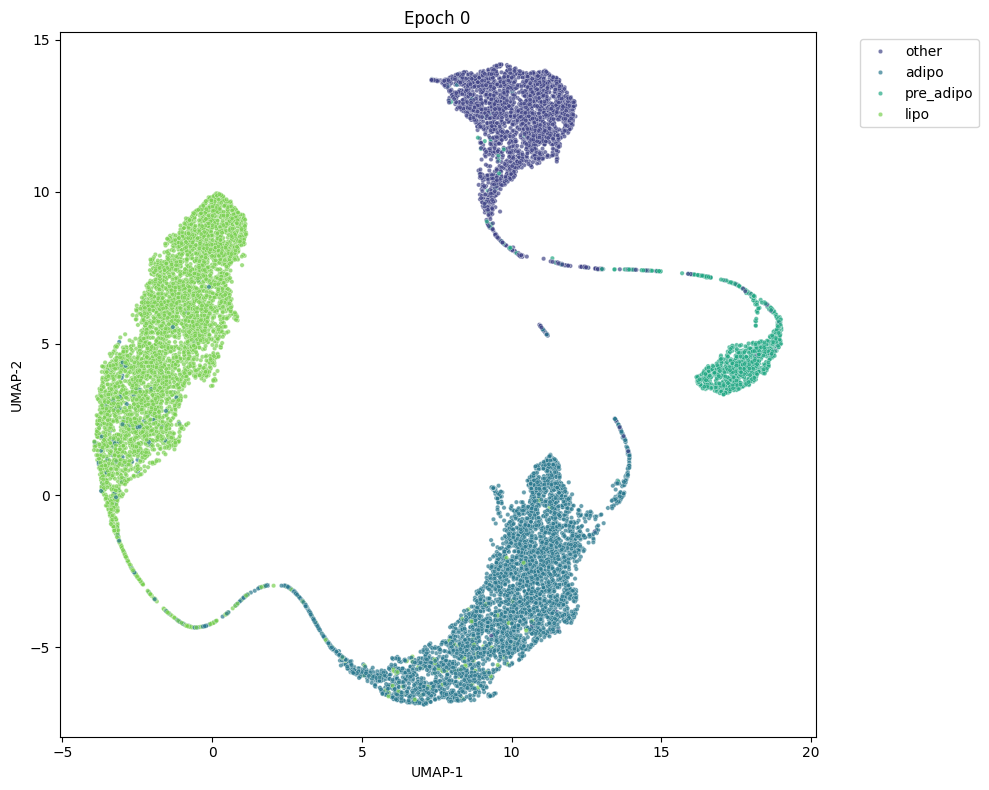

Epoch 9: 100%|█████████▉| 492/493 [06:43<00:00,  1.22it/s, v_num=eae3, Train/loss_cycle_ctrl=0.00241, Train/loss_cycle_pert=0.000791, Train/loss_adv_g=0.324, Train/loss_sem_ctrl=0.0541, Train/loss_sem_pert=0.0279, Train/loss_mmd=0.000635, Train/g_total_loss=1.880, Train/d_loss=0.202, Train/d_real=0.437, Train/d_fake=0.433, val/loss_cycle_ctrl=0.00428, val/loss_cycle_pert=0.00298, val/loss_adv_g=0.315, val/loss_sem_ctrl=0.0605, val/loss_sem_pert=0.042, val/loss_mmd=0.000612, val/g_total_loss=1.910] 

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)


Epoch 10: 100%|██████████| 493/493 [07:11<00:00,  1.14it/s, v_num=eae3, Train/loss_cycle_ctrl=0.00179, Train/loss_cycle_pert=0.00141, Train/loss_adv_g=0.302, Train/loss_sem_ctrl=0.0229, Train/loss_sem_pert=0.0395, Train/loss_mmd=0.000526, Train/g_total_loss=1.720, Train/d_loss=0.208, Train/d_real=0.435, Train/d_fake=0.442, val/loss_cycle_ctrl=0.00371, val/loss_cycle_pert=0.00312, val/loss_adv_g=0.325, val/loss_sem_ctrl=0.0601, val/loss_sem_pert=0.0419, val/loss_mmd=0.000602, val/g_total_loss=1.960]  

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


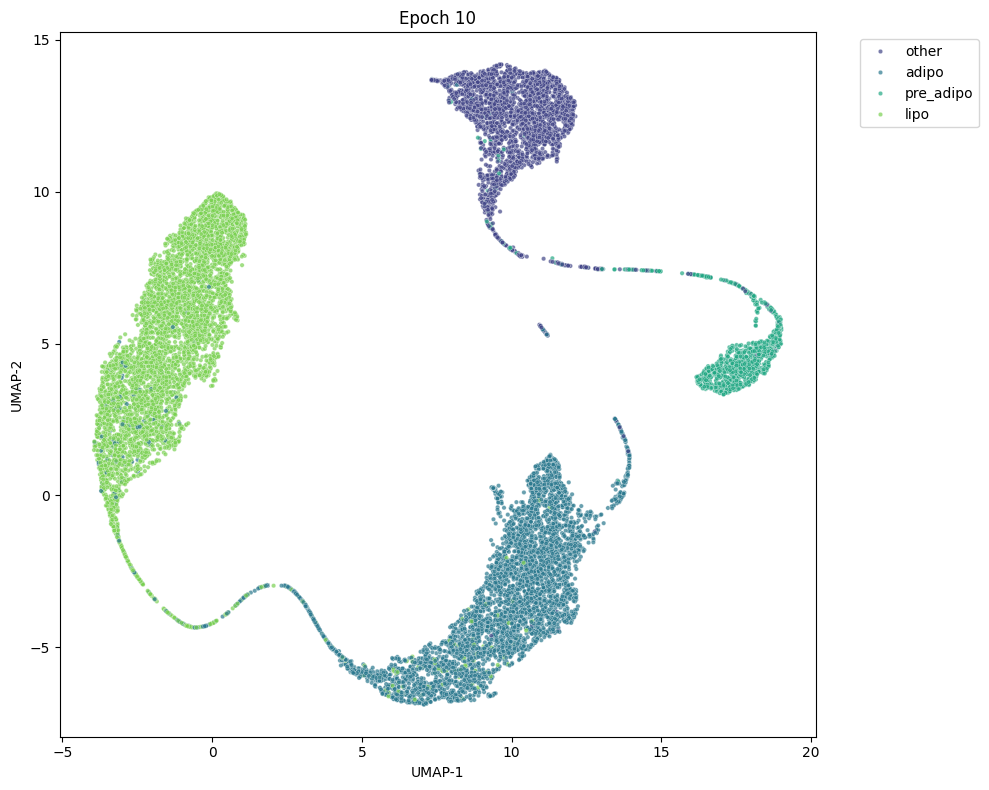

Epoch 12:  76%|███████▌  | 373/493 [06:40<02:09,  0.93it/s, v_num=eae3, Train/loss_cycle_ctrl=0.00148, Train/loss_cycle_pert=0.000805, Train/loss_adv_g=0.305, Train/loss_sem_ctrl=0.0388, Train/loss_sem_pert=0.0293, Train/loss_mmd=0.000642, Train/g_total_loss=1.750, Train/d_loss=0.206, Train/d_real=0.441, Train/d_fake=0.447, val/loss_cycle_ctrl=0.00386, val/loss_cycle_pert=0.00223, val/loss_adv_g=0.298, val/loss_sem_ctrl=0.0603, val/loss_sem_pert=0.0421, val/loss_mmd=0.000575, val/g_total_loss=1.810] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/bdudas/anaconda3/envs/vcell/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [13]:
trainer.fit(model,train_dataloaders=trainloader, val_dataloaders=valloader)